# Introduction to source gradients
Source gradients make it possible to optimize systems in which one simulation produces the illumination for another.<br>
This is useful for multi-stage photonic design problems such as two-level metasurfaces, where the stages can be used for tasks like wavefront pre-shaping, distributing phase control, or correcting aberrations. Without source gradients, a common workflow is to design each stage separately or to optimize a downstream stage under fixed upstream illumination, which makes end-to-end co-design difficult.<br>
In this notebook, we demonstrate the idea with a two-level metalens: the first FDTD simulation generates a bridge field, that field is projected to the second stage as a differentiable custom source, and the second FDTD simulation focuses it to the final target. Because the projected source remains differentiable, gradients from the final objective can flow back through the bridge field into the first simulation.<br>
This lets us co-optimize both metasurfaces without meshing the long free-space region between the two lenses or the long free-space region between the second lens and the focus inside one large FDTD domain.<br>
For more metalens optimization notebooks, see
- [Adjoint Optimization of a Metalens in Tidy3D](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd7Metalens/)
- [Metalens in the visible frequency range](https://www.flexcompute.com/tidy3d/examples/notebooks/Metalens/)
- [Design and shape optimization of a metalens-assisted waveguide taper](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd20MetalensWaveguideTaper/)
- [Mid-IR metalens based on silicon nanopillars](https://www.flexcompute.com/tidy3d/examples/notebooks/MidIRMetalens/)

For introductory notebooks on inverse design with Tidy3D, see
- [Inverse design overview](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd0Overview/)
- [Autograd, automatic differentiation, and adjoint optimization: basics](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd1Intro/)
- [Inverse design quickstart - level 1](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd0Quickstart/)
- [Inverse design quickstart - level 2](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd0QuickstartII/)

<img src="./img/two_level_metalens.jpg" style="width:30%;">


## Setup
We first import the packages needed for the optimization and for plotting.

In [1]:
import autograd.numpy as np
import matplotlib.pyplot as plt
import tidy3d as td
from autograd import value_and_grad
from tidy3d import web
from tidy3d.plugins.autograd import adam, optimize

td.config.logging.level = "ERROR"

Next we define the basic physical and geometric parameters of the two-stage system.

In [2]:
nm = 1e-3  # 1 nanometer in units of microns (for conversion)

wavelength = 850 * nm  # free space central wavelength
f0 = td.C_0 / wavelength  # central frequency
fwidth = f0 / 20  # source pulse width

diameter = 6.0  # diameter of each metalens
height = 430 * nm  # pillar height
period = 320 * nm  # lattice spacing

radius_min = 50 * nm  # minimum pillar radius
radius_max = period / 2 - 10 * nm  # maximum pillar radius

buffer_z = wavelength / 2  # space above and below each metalens
buffer_xy = wavelength  # buffer region in x and y

n_si = 3.84  # refractive index of Si at 850 nm
n_sio2 = 1.45  # refractive index of SiO2 at 850 nm

air = td.Medium(permittivity=1.0)  # air background medium
sio2 = td.Medium(permittivity=n_sio2**2)  # SiO2 substrate medium
si = td.Medium(permittivity=n_si**2)  # Si pillar medium

symmetry = (-1, 1, 0)  # symmetry across x and y
run_time = 100 / fwidth  # simulation run time
min_steps_per_wvl = 10  # minimum steps per wavelength

We now define the derived distances used in the two-stage pipeline.<br>
The first lens sends light to a bridge plane, and the second lens focuses from there to the final focal point.

In [3]:
sim_size_xy = diameter + 2 * buffer_xy  # simulation size in x and y for each lens stage
sim_size_z = height + 2 * buffer_z  # simulation size in z for each lens stage
sim_size = (sim_size_xy, sim_size_xy, sim_size_z)  # full simulation size tuple

focal_length = diameter  # focus location measured from the top surface of the second lens
focal_distance = (
    focal_length - buffer_z / 2
)  # projection distance measured from the near-field monitor plane
bridge_distance = (
    0.5 * focal_distance
)  # distance from the first near-field plane to the bridge plane

source_center = (0, 0, -height / 2 - buffer_z / 2)  # plane-wave source location
near_monitor_center = (0, 0, height / 2 + buffer_z / 2)  # near-field monitor location

plane_size = diameter + buffer_xy  # transverse size of the bridge source plane
bridge_source_center = source_center  # center of the custom source plane for level 2
bridge_source_size = (plane_size, plane_size, 0)  # size of the custom source plane for level 2

pulse = td.GaussianPulse(freq0=f0, fwidth=fwidth, phase=0)  # source time dependence

We divide the problem into two local FDTD simulations and two field-projection steps for the free-space propagation regions.<br>
Before constructing the individual pieces, we first show an overview of the setup.<br>
The sketch below shows the two local simulation boxes, the empty-space regions that are replaced by field projection, and the final focal point.


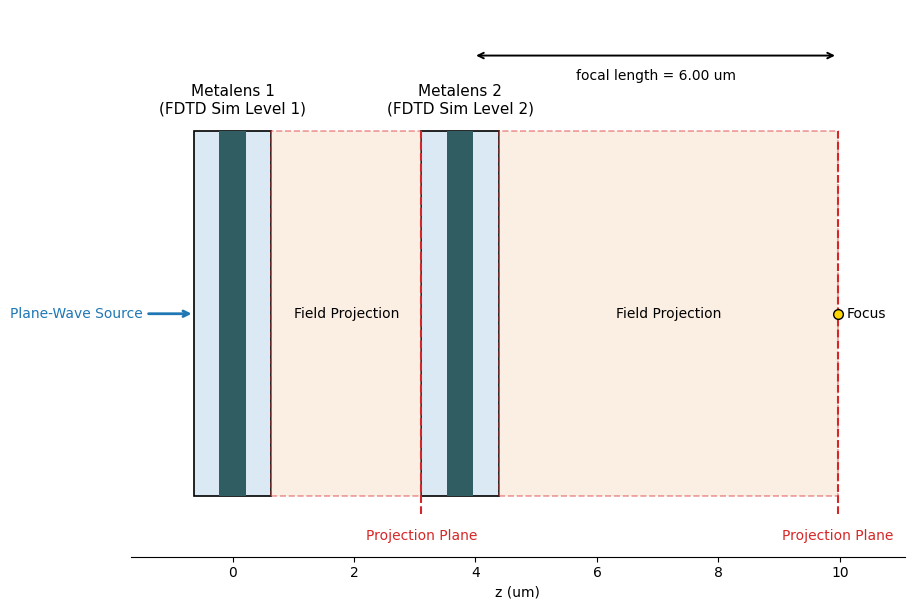

In [4]:
from matplotlib.patches import Rectangle


def plot_two_stage_setup():
    sim1_center_z = 0.0
    sim1_start_z, sim1_end_z = sim1_center_z - sim_size_z / 2, sim1_center_z + sim_size_z / 2

    bridge_plane_z = near_monitor_center[2] + bridge_distance

    # Align the source plane of simulation 2 with the projected bridge plane.
    sim2_center_z = bridge_plane_z - source_center[2]
    sim2_start_z, sim2_end_z = sim2_center_z - sim_size_z / 2, sim2_center_z + sim_size_z / 2

    lens1_start_z = -height / 2
    lens2_start_z, lens2_end_z = sim2_center_z - height / 2, sim2_center_z + height / 2

    # The focus is measured from the top of metalens 2.
    focus_z = sim2_center_z + near_monitor_center[2] + focal_distance

    y_bottom, y_top = -diameter / 2, diameter / 2
    y_center = 0.0
    y_margin_bottom, y_margin_top = 1.0, 2.0
    projection_label_y = y_bottom - 0.55
    focal_arrow_y = y_top + 1.25
    focal_text_y = y_top + 0.8
    line_ymin, line_ymax = y_bottom - 0.3, y_top

    fig, ax = plt.subplots(figsize=(12, 6.2), tight_layout=True)

    sim_color = "#dbe9f4"
    lens_color = "#2f5d62"
    projection_color = "#f7dcc3"

    ax.add_patch(
        Rectangle(
            (sim1_start_z, y_bottom),
            sim_size_z,
            diameter,
            facecolor=sim_color,
            edgecolor="black",
            linewidth=1.2,
        )
    )
    ax.add_patch(
        Rectangle(
            (sim2_start_z, y_bottom),
            sim_size_z,
            diameter,
            facecolor=sim_color,
            edgecolor="black",
            linewidth=1.2,
        )
    )

    ax.add_patch(
        Rectangle(
            (lens1_start_z, y_bottom), height, diameter, facecolor=lens_color, edgecolor="none"
        )
    )
    ax.add_patch(
        Rectangle(
            (lens2_start_z, y_bottom), height, diameter, facecolor=lens_color, edgecolor="none"
        )
    )

    ax.add_patch(
        Rectangle(
            (sim1_end_z, y_bottom),
            sim2_start_z - sim1_end_z,
            diameter,
            facecolor=projection_color,
            edgecolor="tab:red",
            linewidth=1.2,
            linestyle="--",
            alpha=0.45,
        )
    )
    ax.add_patch(
        Rectangle(
            (sim2_end_z, y_bottom),
            focus_z - sim2_end_z,
            diameter,
            facecolor=projection_color,
            edgecolor="tab:red",
            linewidth=1.2,
            linestyle="--",
            alpha=0.45,
        )
    )

    ax.annotate(
        "",
        xy=(source_center[2] - 0.2, y_center),
        xytext=(source_center[2] - 1.0, y_center),
        arrowprops=dict(arrowstyle="->", lw=2, color="tab:blue"),
    )
    ax.text(
        source_center[2] - 1.05,
        y_center,
        "Plane-Wave Source",
        ha="right",
        va="center",
        color="tab:blue",
    )

    ax.text(
        sim1_center_z,
        y_top + 0.25,
        "Metalens 1\n(FDTD Sim Level 1)",
        ha="center",
        va="bottom",
        fontsize=11,
    )
    ax.text(
        sim2_center_z,
        y_top + 0.25,
        "Metalens 2\n(FDTD Sim Level 2)",
        ha="center",
        va="bottom",
        fontsize=11,
    )

    ax.text((sim1_end_z + sim2_start_z) / 2, y_center, "Field Projection", ha="center", va="center")
    ax.text((sim2_end_z + focus_z) / 2, y_center, "Field Projection", ha="center", va="center")

    ax.plot(
        [sim2_start_z, sim2_start_z],
        [line_ymin, line_ymax],
        color="tab:red",
        linestyle="--",
        linewidth=1.5,
    )
    ax.plot(
        [focus_z, focus_z], [line_ymin, line_ymax], color="tab:red", linestyle="--", linewidth=1.5
    )
    ax.text(
        sim2_start_z,
        projection_label_y,
        "Projection Plane",
        ha="center",
        va="top",
        color="tab:red",
    )
    ax.text(
        focus_z,
        projection_label_y,
        "Projection Plane",
        ha="center",
        va="top",
        color="tab:red",
    )

    ax.plot(focus_z, y_center, marker="o", markersize=7, color="gold", markeredgecolor="black")
    ax.text(focus_z + 0.15, y_center, "Focus", ha="left", va="center")

    ax.annotate(
        "",
        xy=(lens2_end_z, focal_arrow_y),
        xytext=(focus_z, focal_arrow_y),
        arrowprops=dict(arrowstyle="<->", lw=1.4, color="black"),
    )
    ax.text(
        (lens2_end_z + focus_z) / 2,
        focal_text_y,
        f"focal length = {focal_length:.2f} um",
        ha="center",
        va="bottom",
    )

    ax.set_xlim(source_center[2] - 1.25, focus_z + 1.1)
    ax.set_ylim(y_bottom - y_margin_bottom, y_top + y_margin_top)
    ax.set_xlabel("z (um)")
    ax.set_yticks([])
    ax.spines[["left", "right", "top"]].set_visible(False)
    ax.set_aspect("equal", adjustable="box")

    plt.show()


plot_two_stage_setup()

## Create the Two Metasurfaces
We use circular Si pillars on an SiO2 substrate. Symmetry allows us to model only one quadrant of each metasurface in the simulation.


In [5]:
def get_cylinder_centers(diameter, spacing, full_circle=False):
    r_eff = diameter / 2 - spacing / 2
    coords = np.arange(0.0, r_eff, spacing)
    if full_circle:
        positive_coords = coords[coords > 0]
        coords = np.concatenate((-positive_coords[::-1], coords))
    x_grid, y_grid = np.meshgrid(coords, coords)
    points = np.vstack((x_grid.ravel(), y_grid.ravel())).T
    mask = x_grid**2 + y_grid**2 <= r_eff**2
    points = points[mask.ravel()]
    if full_circle:
        return points
    return points[(points[:, 0] >= -1e-12) & (points[:, 1] >= -1e-12)]


centers_quarter = get_cylinder_centers(diameter, period, full_circle=False)
centers_full = get_cylinder_centers(diameter, period, full_circle=True)

print(f"Independent cylinders per lens: {len(centers_quarter)}")
print(f"Physical cylinders per lens: {len(centers_full)}")
print(f"focal_length = {focal_length:.2f} um")
print(f"bridge_distance = {bridge_distance:.2f} um")
print(f"focal_distance = {focal_distance:.2f} um")

Independent cylinders per lens: 69
Physical cylinders per lens: 241
focal_length = 6.00 um
bridge_distance = 2.89 um
focal_distance = 5.79 um


Let's visualize the pillar center coordinates across the full circular aperture.

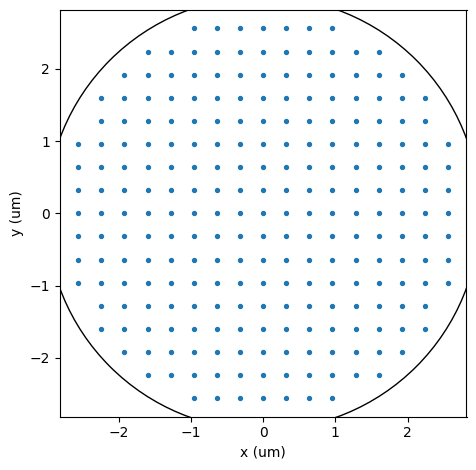

In [6]:
fig, ax = plt.subplots(1, 1, tight_layout=True)
ax.scatter(*centers_full.T, s=8)
ax.add_artist(plt.Circle((0, 0), diameter / 2, color="black", fill=False))
ax.set_xlabel("x (um)")
ax.set_ylabel("y (um)")
ax.set_aspect("equal")
plt.show()

Next we define the substrate, the aperture structures, and a helper that turns optimization parameters into grouped cylinder geometries.

In [7]:
substrate = td.Structure(
    geometry=td.Box.from_bounds(
        rmin=(-td.inf, -td.inf, -1000),
        rmax=(td.inf, td.inf, -height / 2),
    ),
    medium=sio2,
)

aperture = [
    td.Structure(
        geometry=td.Box.from_bounds(
            rmin=(-td.inf, -td.inf, -height / 2),
            rmax=(td.inf, td.inf, -height / 2 + 0.2),
        ),
        medium=td.PECMedium(),
    ),
    td.Structure(
        geometry=td.Cylinder(
            center=(0, 0, 0),
            radius=diameter / 2 + buffer_xy / 4,
            length=height,
        ),
        medium=air,
    ),
]


def params_to_radii(params):
    return radius_min + (radius_max - radius_min) / (1 + np.exp(-params))


def make_cylinders(params):
    radii = params_to_radii(params)
    geometries = []
    for radius, (x_pos, y_pos) in zip(radii, centers_quarter):
        geometries.append(td.Cylinder(center=(x_pos, y_pos, 0), radius=radius, length=height))
    return td.Structure(
        geometry=td.GeometryGroup(geometries=geometries),
        medium=si,
    )

## Define the Source and Monitors
Level 1 is illuminated by a plane wave. The field just above level 1 is projected to the bridge plane and reused as the source of level 2. After level 2, we project to the focal point and to a few visualization planes instead of extending the FDTD domain through the free-space propagation region.


In [8]:
level1_source = td.PlaneWave(
    source_time=pulse,
    size=(td.inf, td.inf, 0),
    center=source_center,
    direction="+",
    pol_angle=0,
)

level1_near_monitor = td.FieldMonitor(
    center=near_monitor_center,
    size=(td.inf, td.inf, 0),
    freqs=[f0],
    name="level1_near",
    colocate=False,
)

level2_near_monitor = td.FieldMonitor(
    center=near_monitor_center,
    size=(td.inf, td.inf, 0),
    freqs=[f0],
    name="level2_near",
    colocate=False,
)


def make_symmetric_axis(span, spacing):
    half_steps = max(1, int(np.floor((span / 2) / spacing)))
    max_coord = half_steps * spacing
    return np.linspace(-max_coord, max_coord, 2 * half_steps + 1)


def make_positive_axis(span, spacing):
    num_steps = max(1, int(np.floor(span / spacing)))
    return spacing * np.arange(0, num_steps + 1, dtype=float)


# sampling of the projected bridge field
bridge_grid_spacing = period

# finer sampling used for visualization plots
plot_grid_spacing = period / 5

# transverse span of the final field plots
focus_span = 2.0

# x coordinates on the bridge plane
bridge_x = make_symmetric_axis(plane_size, bridge_grid_spacing)

# y coordinates on the bridge plane
bridge_y = make_symmetric_axis(plane_size, bridge_grid_spacing)

# x coordinates on the final focal plane
focus_x = make_symmetric_axis(focus_span, plot_grid_spacing)

# y coordinates on the final focal plane
focus_y = make_symmetric_axis(focus_span, plot_grid_spacing)

# transverse coordinate of the axial cross section
axial_y = make_symmetric_axis(focus_span, plot_grid_spacing)

# propagation coordinate of the axial cross section
axial_z = make_positive_axis(focal_distance + buffer_z, plot_grid_spacing)[1:]

# monitor used to project from level 1 to the bridge plane
bridge_monitor = td.FieldProjectionCartesianMonitor(
    center=level1_near_monitor.center,
    size=level1_near_monitor.size,
    freqs=level1_near_monitor.freqs,
    name="bridge_projection",
    x=bridge_x,
    y=bridge_y,
    proj_axis=2,
    proj_distance=bridge_distance,
    far_field_approx=False,
    custom_origin=level1_near_monitor.center,
)

# monitor used to evaluate on-axis focusing after level 2
focus_point_monitor = td.FieldProjectionAngleMonitor(
    center=level2_near_monitor.center,
    size=level2_near_monitor.size,
    freqs=level2_near_monitor.freqs,
    name="focus_point_projection",
    phi=[0],
    theta=[0],
    proj_distance=focal_distance,
    far_field_approx=False,
    custom_origin=level2_near_monitor.center,
)

# monitor used to visualize the projected focal plane after level 2
focus_plane_monitor = td.FieldProjectionCartesianMonitor(
    center=level2_near_monitor.center,
    size=level2_near_monitor.size,
    freqs=level2_near_monitor.freqs,
    name="focus_plane_projection",
    x=focus_x,
    y=focus_y,
    proj_axis=2,
    proj_distance=focal_distance,
    far_field_approx=False,
    custom_origin=level2_near_monitor.center,
)

## Build the Simulations
Each lens uses the same geometry template. We keep each FDTD domain short and connect the stages with field projection, so the free-space gap between the two lenses does not need to be meshed explicitly.


In [9]:
boundary_spec = td.BoundarySpec.all_sides(td.PML())
grid_spec = td.GridSpec.auto(min_steps_per_wvl=min_steps_per_wvl)


def make_level1_sim(params):
    structures = [substrate, *aperture]
    if params is not None:
        structures.append(make_cylinders(params))
    return td.Simulation(
        size=sim_size,
        structures=structures,
        sources=[level1_source],
        monitors=[level1_near_monitor],
        run_time=run_time,
        boundary_spec=boundary_spec,
        grid_spec=grid_spec,
        symmetry=symmetry,
    )


def projection_to_field_dataset(projected_fields):
    fields_cartesian = projected_fields.fields_cartesian
    z_values = fields_cartesian.coords["z"].values
    z_values = z_values - z_values[0]
    coords = {
        "x": fields_cartesian.coords["x"].values,
        "y": fields_cartesian.coords["y"].values,
        "z": z_values,
        "f": fields_cartesian.coords["f"].values,
    }
    field_components = {}
    for field_name in ("Ex", "Ey", "Ez", "Hx", "Hy", "Hz"):
        field_data = fields_cartesian[field_name]
        field_components[field_name] = td.ScalarFieldDataArray(
            field_data.data,
            coords=coords,
            dims=field_data.dims,
        )
    return td.FieldDataset(**field_components)


def make_bridge_source(sim_data_level1):
    projector = td.FieldProjector.from_near_field_monitors(
        sim_data=sim_data_level1,
        near_monitors=[level1_near_monitor],
        normal_dirs=["+"],
        pts_per_wavelength=None,
        origin=level1_near_monitor.center,
    )
    projected_bridge_fields = projector.project_fields(bridge_monitor, verbose=False)
    bridge_dataset = projection_to_field_dataset(projected_bridge_fields)
    return td.CustomFieldSource(
        center=bridge_source_center,
        size=bridge_source_size,
        source_time=pulse,
        field_dataset=bridge_dataset,
    )


def make_level2_sim(params, bridge_source):
    structures = [substrate, *aperture]
    if params is not None:
        structures.append(make_cylinders(params))
    return td.Simulation(
        size=sim_size,
        structures=structures,
        sources=[bridge_source],
        monitors=[level2_near_monitor],
        run_time=run_time,
        boundary_spec=boundary_spec,
        grid_spec=grid_spec,
        symmetry=symmetry,
    )

Let's inspect the geometry of one lens before starting the optimization.

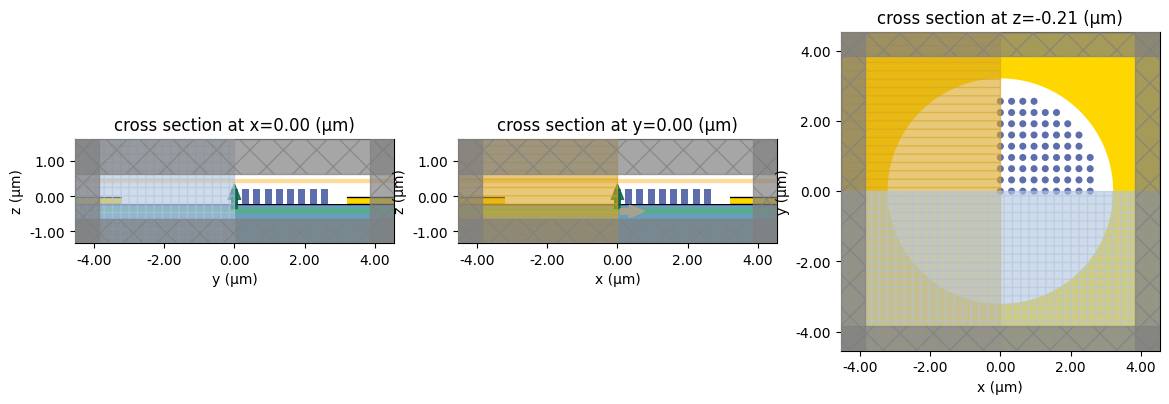

In [10]:
params0_level1 = np.zeros(len(centers_quarter))
params0_level2 = np.zeros(len(centers_quarter))
params0 = np.concatenate((params0_level1, params0_level2))

sim0 = make_level1_sim(params0_level1)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 5))

sim0.plot(x=0, ax=ax1)
sim0.plot(y=0, ax=ax2)
sim0.plot(z=-height / 2, ax=ax3)

plt.show()

## Objective Function
We now define the two-stage optimization pipeline:<br>
The first simulation generates the bridge source, the second simulation focuses the field, and the final objective is the projected on-axis power at the focal point. The projection step also removes the need to simulate the full free-space propagation distance from the second lens to the focus with FDTD. The normalized objective reported below is this on-axis power divided by the empty-device value, while the focused power itself is not normalized to the total input power. Because the bridge source is differentiable, this chained setup still supports an end-to-end gradient.


In [11]:
def split_params(params_all):
    return params_all[: len(centers_quarter)], params_all[len(centers_quarter) :]


def run_two_level(params_level1, params_level2, tag):
    # Run the first simulation with the plane-wave source.
    sim_level1 = make_level1_sim(params_level1)
    sim_data_level1 = web.run(
        sim_level1, task_name=f"intro_source_gradients_level1_{tag}", verbose=False
    )

    # Project the first near field to the bridge plane and reuse it as a custom source.
    bridge_source = make_bridge_source(sim_data_level1)

    # Run the second simulation with the projected bridge field as illumination.
    sim_level2 = make_level2_sim(params_level2, bridge_source)
    sim_data_level2 = web.run(
        sim_level2, task_name=f"intro_source_gradients_level2_{tag}", verbose=False
    )
    return sim_data_level1, sim_data_level2


def measure_focal_power(sim_data_level2):
    projector = td.FieldProjector.from_near_field_monitors(
        sim_data=sim_data_level2,
        near_monitors=[level2_near_monitor],
        normal_dirs=["+"],
        pts_per_wavelength=None,
        origin=level2_near_monitor.center,
    )
    projected_focus = projector.project_fields(focus_point_monitor, verbose=False)
    return np.sum(np.real(projected_focus.power.values))


def J_absolute(params_all):
    params_level1, params_level2 = split_params(params_all)
    _, sim_data_level2 = run_two_level(params_level1, params_level2, tag="opt")
    return measure_focal_power(sim_data_level2)


_, sim_data_empty = run_two_level(None, None, tag="empty")
J_empty = float(measure_focal_power(sim_data_empty))


def J(params_all):
    return J_absolute(params_all) / J_empty


dJ = value_and_grad(J)

We can now evaluate the initial objective value and the initial gradient norm.

In [12]:
value0, gradient0 = dJ(params0)
print(f"baseline focused power = {J_empty:.4f}")
print(f"initial normalized objective = {value0:.3f}")
print(f"initial focused power = {value0 * J_empty:.4f}")
print(f"initial gradient norm = {np.linalg.norm(gradient0):.3f}")

baseline focused power = 0.0413
initial normalized objective = 0.637
initial focused power = 0.0263
initial gradient norm = 0.331


## Optimization
We optimize both metasurfaces end-to-end. During optimization, we track the objective value and the gradient norm.


In [13]:
num_steps = 20
learning_rate = 1e-1

optimizer = adam(learning_rate=learning_rate)


def print_step(_params, gradient, _state, step_index, objective_value):
    value = float(objective_value)
    print(f"step = {step_index + 1}")
    print(f"	normalized objective = {value:.3f}")
    print(f"	focused power = {value * J_empty:.4f}")
    print(f"	gradient norm = {np.linalg.norm(gradient):.3f}")


params, _, opt_history = optimize(
    J,
    params0=np.copy(params0),
    optimizer=optimizer,
    num_steps=num_steps,
    callback=print_step,
    direction="max",
)
J_history = opt_history["objective_fn_val"]

step = 1
	normalized objective = 0.637
	focused power = 0.0263
	gradient norm = 0.331
step = 2
	normalized objective = 1.493
	focused power = 0.0616
	gradient norm = 0.418
step = 3
	normalized objective = 2.240
	focused power = 0.0924
	gradient norm = 0.643
step = 4
	normalized objective = 2.765
	focused power = 0.1141
	gradient norm = 0.997
step = 5
	normalized objective = 3.245
	focused power = 0.1339
	gradient norm = 0.544
step = 6
	normalized objective = 3.563
	focused power = 0.1470
	gradient norm = 0.571
step = 7
	normalized objective = 3.919
	focused power = 0.1617
	gradient norm = 0.741
step = 8
	normalized objective = 4.090
	focused power = 0.1688
	gradient norm = 1.379
step = 9
	normalized objective = 4.407
	focused power = 0.1819
	gradient norm = 1.093
step = 10
	normalized objective = 4.696
	focused power = 0.1938
	gradient norm = 0.867
step = 11
	normalized objective = 4.907
	focused power = 0.2025
	gradient norm = 0.709
step = 12
	normalized objective = 5.172
	focused pow

The objective history below shows the normalized focusing enhancement over the optimization iterations.

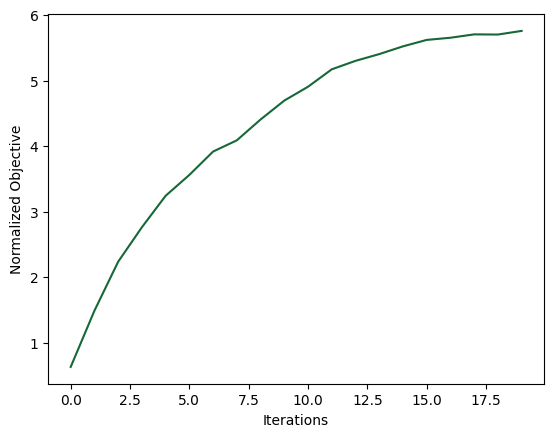

In [14]:
plt.plot(J_history)
plt.xlabel("Iterations")
plt.ylabel("Normalized Objective")
plt.show()

## Final Designs
We first look at the optimized pillar layouts for the two metasurfaces.


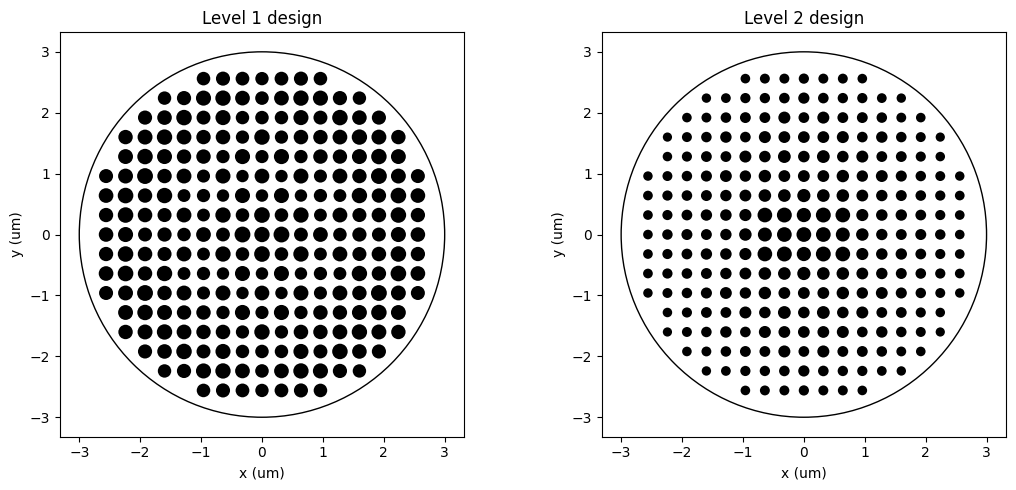

In [15]:
def expand_design_with_symmetry(centers, radii):
    seen = set()
    full_centers = []
    full_radii = []
    for (x_pos, y_pos), radius in zip(centers, radii):
        for sign_x in (-1.0, 1.0):
            for sign_y in (-1.0, 1.0):
                x_coord = float(sign_x * x_pos)
                y_coord = float(sign_y * y_pos)
                key = (round(x_coord, 12), round(y_coord, 12))
                if key in seen:
                    continue
                seen.add(key)
                full_centers.append((x_coord, y_coord))
                full_radii.append(float(radius))
    return full_centers, full_radii


def plot_design(axis, radii, title):
    centers_plot, radii_plot = expand_design_with_symmetry(centers_quarter, radii)
    for (x_coord, y_coord), radius in zip(centers_plot, radii_plot):
        axis.add_patch(plt.Circle((x_coord, y_coord), radius, facecolor="black", edgecolor="none"))
    axis.add_patch(plt.Circle((0, 0), diameter / 2, color="black", fill=False, linewidth=1.0))
    span = diameter / 2 + period
    axis.set_xlim(-span, span)
    axis.set_ylim(-span, span)
    axis.set_xlabel("x (um)")
    axis.set_ylabel("y (um)")
    axis.set_title(title)
    axis.set_aspect("equal")


params_level1_after, params_level2_after = split_params(params)

radii_level1_after = params_to_radii(params_level1_after)
radii_level2_after = params_to_radii(params_level2_after)

fig, axes = plt.subplots(1, 2, figsize=(11, 5), tight_layout=True)

plot_design(axes[0], radii_level1_after, "Level 1 design")
plot_design(axes[1], radii_level2_after, "Level 2 design")

plt.show()

## Projected Fields
To visualize the result, we rerun the optimized two-stage system and project the fields to the bridge plane, to the focal plane, and to an axial plane through the focus. These projections again let us inspect the long-distance propagation without enlarging the FDTD domain.


In [16]:
def project_bridge_plane(sim_data_level1):
    projector = td.FieldProjector.from_near_field_monitors(
        sim_data=sim_data_level1,
        near_monitors=[level1_near_monitor],
        normal_dirs=["+"],
        pts_per_wavelength=min_steps_per_wvl,
        origin=level1_near_monitor.center,
    )
    return projector.project_fields(bridge_monitor, verbose=False)


def project_focus_plane(sim_data_level2):
    projector = td.FieldProjector.from_near_field_monitors(
        sim_data=sim_data_level2,
        near_monitors=[level2_near_monitor],
        normal_dirs=["+"],
        pts_per_wavelength=min_steps_per_wvl,
        origin=level2_near_monitor.center,
    )
    return projector.project_fields(focus_plane_monitor, verbose=False)


def project_focus_axial_plane(sim_data_level2):
    axial_monitor = td.FieldProjectionCartesianMonitor(
        center=level2_near_monitor.center,
        size=level2_near_monitor.size,
        freqs=level2_near_monitor.freqs,
        name="focus_axial_projection",
        x=axial_y,
        y=axial_z,
        proj_axis=0,
        proj_distance=0,
        far_field_approx=False,
        custom_origin=level2_near_monitor.center,
    )
    projector = td.FieldProjector.from_near_field_monitors(
        sim_data=sim_data_level2,
        near_monitors=[level2_near_monitor],
        normal_dirs=["+"],
        pts_per_wavelength=min_steps_per_wvl,
        origin=level2_near_monitor.center,
    )
    return projector.project_fields(axial_monitor, verbose=False)


sim_data_level1_after, sim_data_level2_after = run_two_level(
    params_level1_after,
    params_level2_after,
    tag="final",
)
final_on_axis_power = float(measure_focal_power(sim_data_level2_after))

bridge_plane_data = project_bridge_plane(sim_data_level1_after)
focus_plane_data = project_focus_plane(sim_data_level2_after)
axial_plane_data = project_focus_axial_plane(sim_data_level2_after)

print(f"final focused power = {final_on_axis_power:.4f}")
print(f"final normalized objective = {final_on_axis_power / J_empty:.3f}")

final focused power = 0.2392
final normalized objective = 5.796


Now we visualize the projected field intensity at three locations: the bridge plane between the two lenses, the focal plane, and the axial cross section through the focus.


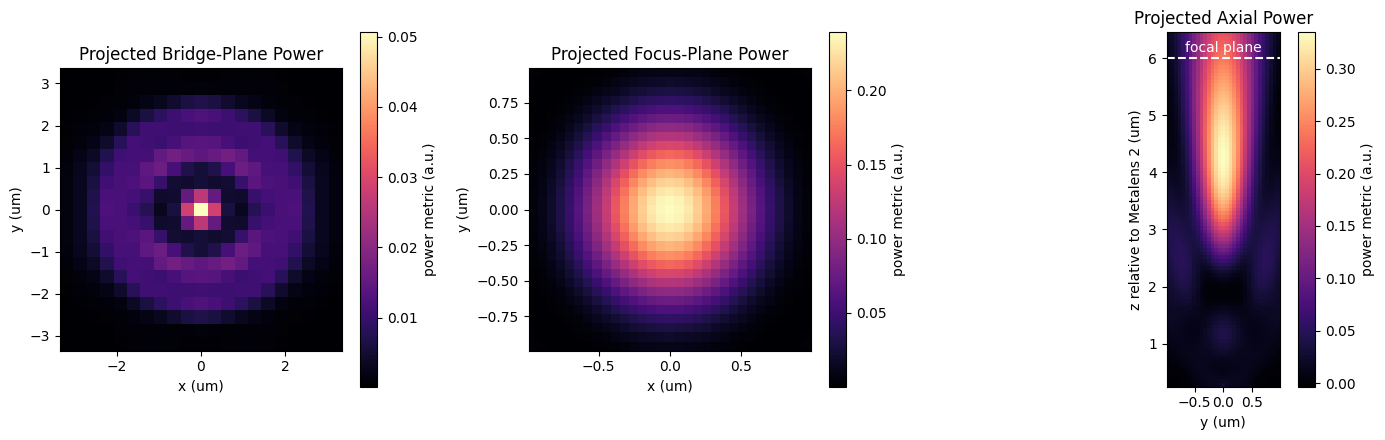

In [25]:
bridge_power = np.squeeze(np.real(bridge_plane_data.power.values))
focus_power = np.squeeze(np.real(focus_plane_data.power.values))
axial_power = np.squeeze(np.real(axial_plane_data.power.values))
axial_z_plot = axial_plane_data.z + buffer_z / 2

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4.5), tight_layout=True)

mesh1 = ax1.pcolormesh(
    bridge_plane_data.x,
    bridge_plane_data.y,
    bridge_power.T,
    shading="auto",
    cmap="magma",
)
ax1.set_xlabel("x (um)")
ax1.set_ylabel("y (um)")
ax1.set_title("Projected Bridge-Plane Power")
ax1.set_aspect("equal")
fig.colorbar(mesh1, ax=ax1, label="power metric (a.u.)")

mesh2 = ax2.pcolormesh(
    focus_plane_data.x,
    focus_plane_data.y,
    focus_power.T,
    shading="auto",
    cmap="magma",
)
ax2.set_xlabel("x (um)")
ax2.set_ylabel("y (um)")
ax2.set_title("Projected Focus-Plane Power")
ax2.set_aspect("equal")
fig.colorbar(mesh2, ax=ax2, label="power metric (a.u.)")

mesh3 = ax3.pcolormesh(
    axial_plane_data.y,
    axial_z_plot,
    axial_power.T,
    shading="auto",
    cmap="magma",
)
ax3.axhline(focal_length, color="white", linestyle="--", linewidth=1.5)
ax3.text(
    0,
    focal_length + 0.05,
    "focal plane",
    color="white",
    ha="center",
    va="bottom",
)
ax3.set_xlabel("y (um)")
ax3.set_ylabel("z relative to Metalens 2 (um)")
ax3.set_title("Projected Axial Power")
ax3.set_aspect("equal")
fig.colorbar(mesh3, ax=ax3, label="power metric (a.u.)")

plt.show()

## Conclusions
This example shows how source gradients can propagate through a multi-stage workflow in which one simulation generates the source for another.<br>
The field projector is used both to couple the two metasurfaces and to evaluate the final focusing performance, while the optimization still sees the whole pipeline as a single differentiable objective.


For more related case studies, see the<br>
* [Gradient Checking Notebook](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd2GradientChecking/).<br>
* [Inverse Design Notebook](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd3InverseDesign/).<br>
* [Metalens Notebook](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd7Metalens/).<br>
* [Metasurface Notebook](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd13Metasurface/).<br>
* [Metalens Waveguide Taper Notebook](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd20MetalensWaveguideTaper/).<br>
* [Fiber Lens Notebook](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd28FiberLens/)
